In [14]:
# -----------------------------------------------------------
# Check GPU availability on puffer server
# -----------------------------------------------------------
!nvidia-smi

import torch

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")

# Check current device
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Sun Sep 28 23:04:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     Off |   00000000:84:00.0 Off |                  N/A |
| 24%   36C    P8             24W /  250W |       4MiB /  11264MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
import cv2, numpy, matplotlib, torch
print("OpenCV:", cv2.__version__)
print("NumPy:", numpy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Torch:", torch.__version__)


OpenCV: 4.12.0
NumPy: 2.2.0
Matplotlib: 3.10.6
Torch: 2.8.0+cu128


In [35]:
import os
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split, Subset
import numpy as np

In [36]:
# Proxy setup (needed on puffer server)
os.environ['http_proxy'] = 'http://192.41.170.23:3128'

In [ ]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

In [37]:
#Data Preparation
#Transform: resize to 224x224, normalize with ImageNet-like stats
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])  #????
])

In [38]:
train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

In [39]:
#Subsample to 1000 total samples (train+val+test)
subset_size = 1000
indices = np.random.choice(len(train_dataset), subset_size, replace=False)
small_dataset = Subset(train_dataset, indices)

In [40]:
# Split into Train (80%), Val (20%), Test (use CIFAR test split here as 400)
train_size = int(0.8 * len(small_dataset))
val_size   = len(small_dataset) - train_size
train_subset, val_subset = random_split(small_dataset, [train_size, val_size])

In [41]:
batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}")

Train: 800 | Val: 200 | Test: 10000


In [42]:
#Helper Function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

def train_epoch(model, optimizer, loss_fn):
    model.train()
    total, correct, running_loss = 0, 0, 0.0
    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / len(train_loader), correct / total

def validate_epoch(model, loss_fn):
    model.eval()
    total, correct, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for data, labels in val_loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / len(val_loader), correct / total

# def test_model(model):
#     model.eval()
#     correct, total = 0, 0
#     with torch.no_grad():
#         for data, labels in test_loader:
#             data, labels = data.to(device), labels.to(device)
#             outputs = model(data)
#             preds = outputs.argmax(dim=1)
#             correct += (preds == labels).sum().item()
#             total += labels.size(0)
#     return correct / total

In [43]:
#2 Convultional Layers

print(f"Training on device: {device}")

Training on device: cuda:1


In [28]:
class CNN2Conv(nn.Module):
    def __init__(self):
        super(CNN2Conv, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=11, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, stride=1)
        self.pool  = nn.MaxPool2d(kernel_size=3, stride=2)
        self.flatten = nn.Flatten()
        
        with torch.no_grad(): #calculate flatten size
            sample = torch.zeros(1,3,224,224)
            conv_out = self._forward_features(sample)
            flatten_dim = conv_out.view(1,-1).size(1)

            
        self.fc1 = nn.Linear(flatten_dim, 1024)
        self.fc2 = nn.Linear(1024, 10)
        
    def _forward_features(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        return x
        
    def forward(self, x):
        x = self._forward_features(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model1 = CNN2Conv().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001)

num_epochs = 15
# Trackers
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    tr_loss, tr_acc = train_epoch(model1, optimizer, loss_fn)
    va_loss, va_acc = validate_epoch(model1, loss_fn)
    train_losses1.append(tr_loss); val_losses1.append(va_loss)
    train_accs1.append(tr_acc);   val_accs1.append(va_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | Val Loss: {va_loss:.4f}, Acc: {va_acc:.4f}")

test_acc1 = test_model(model1)
print("Final Test Accuracy (2-Conv CNN):", test_acc1)
num_params1 = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print("Total Learnable Parameters (2-Conv CNN):", num_params1)

Epoch [1/15] Train Loss: 2.3273, Acc: 0.1825 | Val Loss: 2.0459, Acc: 0.2450
Epoch [2/15] Train Loss: 2.0381, Acc: 0.2625 | Val Loss: 1.9874, Acc: 0.2600
Epoch [3/15] Train Loss: 1.8428, Acc: 0.3450 | Val Loss: 1.7886, Acc: 0.3400
Epoch [4/15] Train Loss: 1.7017, Acc: 0.3738 | Val Loss: 1.7368, Acc: 0.3800
Epoch [5/15] Train Loss: 1.5120, Acc: 0.4550 | Val Loss: 1.8045, Acc: 0.3100
Epoch [6/15] Train Loss: 1.3481, Acc: 0.5138 | Val Loss: 1.7886, Acc: 0.3600
Epoch [7/15] Train Loss: 1.2411, Acc: 0.5575 | Val Loss: 1.7782, Acc: 0.3100
Epoch [8/15] Train Loss: 1.0143, Acc: 0.6388 | Val Loss: 1.8201, Acc: 0.3700
Epoch [9/15] Train Loss: 0.7378, Acc: 0.7425 | Val Loss: 2.0730, Acc: 0.3850
Epoch [10/15] Train Loss: 0.5538, Acc: 0.8037 | Val Loss: 2.1530, Acc: 0.4050
Epoch [11/15] Train Loss: 0.3189, Acc: 0.8975 | Val Loss: 2.3166, Acc: 0.3600
Epoch [12/15] Train Loss: 0.1695, Acc: 0.9600 | Val Loss: 2.8942, Acc: 0.4150
Epoch [13/15] Train Loss: 0.0929, Acc: 0.9762 | Val Loss: 2.9010, Acc: 0.

# 3 convulutional layer > 3 x 3 kernel sizes
### 2 max pooling layers 3x3 sizes

In [29]:
print(f"Training on device: {device}")

Training on device: cuda:1


In [30]:
print("\n===== Training Q5.2: 3-Conv CNN =====")
print(f"Training on device: {device}")

class CNN3Conv(nn.Module):
    def __init__(self):
        super(CNN3Conv, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=3, stride=2)
        self.flatten = nn.Flatten()
        with torch.no_grad():
            sample = torch.zeros(1,3,224,224)
            conv_out = self._forward_features(sample)
            flatten_dim = conv_out.view(1,-1).size(1)
        self.fc1 = nn.Linear(flatten_dim, 1024)
        self.fc2 = nn.Linear(1024, 10)
    def _forward_features(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        return x
    def forward(self, x):
        x = self._forward_features(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model2 = CNN3Conv().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)

train_losses2, val_losses2, train_accs2, val_accs2 = [], [], [], []
for epoch in range(num_epochs):
    tr_loss, tr_acc = train_epoch(model2, optimizer, loss_fn)
    va_loss, va_acc = validate_epoch(model2, loss_fn)
    train_losses2.append(tr_loss); val_losses2.append(va_loss)
    train_accs2.append(tr_acc);   val_accs2.append(va_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | Val Loss: {va_loss:.4f}, Acc: {va_acc:.4f}")

test_acc2 = test_model(model2)
print("Final Test Accuracy (3-Conv CNN):", test_acc2)
num_params2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print("Total Learnable Parameters (3-Conv CNN):", num_params2)


===== Training Q5.2: 3-Conv CNN =====
Training on device: cuda:1
Epoch [1/15] Train Loss: 4.5977, Acc: 0.1400 | Val Loss: 2.1340, Acc: 0.2250
Epoch [2/15] Train Loss: 1.9528, Acc: 0.2900 | Val Loss: 2.0368, Acc: 0.2900
Epoch [3/15] Train Loss: 1.6573, Acc: 0.4425 | Val Loss: 1.8062, Acc: 0.4050
Epoch [4/15] Train Loss: 1.3383, Acc: 0.5175 | Val Loss: 1.8308, Acc: 0.3750
Epoch [5/15] Train Loss: 1.0299, Acc: 0.6388 | Val Loss: 2.1204, Acc: 0.3800
Epoch [6/15] Train Loss: 0.7372, Acc: 0.7588 | Val Loss: 2.1664, Acc: 0.4000
Epoch [7/15] Train Loss: 0.5015, Acc: 0.8662 | Val Loss: 2.2485, Acc: 0.3900
Epoch [8/15] Train Loss: 0.2249, Acc: 0.9413 | Val Loss: 3.4003, Acc: 0.3850
Epoch [9/15] Train Loss: 0.1614, Acc: 0.9525 | Val Loss: 3.7910, Acc: 0.3600
Epoch [10/15] Train Loss: 0.1643, Acc: 0.9650 | Val Loss: 3.4780, Acc: 0.3600
Epoch [11/15] Train Loss: 0.1187, Acc: 0.9725 | Val Loss: 4.3171, Acc: 0.3500
Epoch [12/15] Train Loss: 0.1246, Acc: 0.9688 | Val Loss: 3.4732, Acc: 0.3450
Epoch [

### Comparison ,performance and weakness

In [31]:
import pandas as pd
from IPython.display import Markdown

results = {
    "Model": ["2-Conv CNN (11x11, 5x5)", "3-Conv CNN (3x3, 3x3, 3x3)"],
    "Test Accuracy": [f"{test_acc1:.4f}", f"{test_acc2:.4f}"],
    "Learnable Parameters": [f"{num_params1:,}", f"{num_params2:,}"]
}
df_results = pd.DataFrame(results)

print("Final Summary of Results (Q5.1–Q5.3)")
display(df_results)

Final Summary of Results (Q5.1–Q5.3)


,Model,Test Accuracy,Learnable Parameters
0,"2-Conv CNN (11x11, 5x5)",0.3626,"6,627,786"
1,"3-Conv CNN (3x3, 3x3, 3x3)",0.3475,"396,597,322"


/opt/tljh/user/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


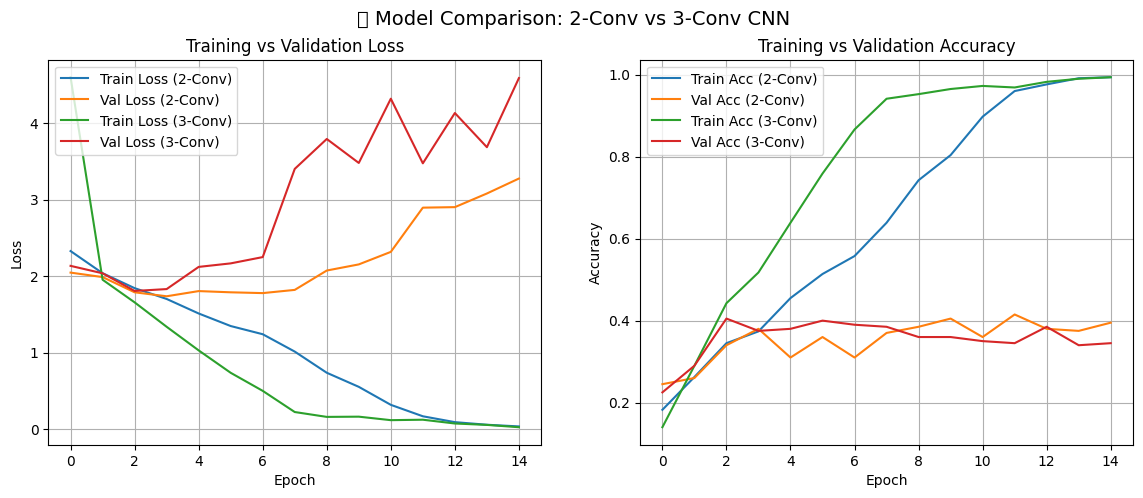

In [32]:
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Side-by-side plots: 2-Conv vs 3-Conv
# -----------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Plot Loss
axes[0].plot(train_losses1, label="Train Loss (2-Conv)")
axes[0].plot(val_losses1, label="Val Loss (2-Conv)")
axes[0].plot(train_losses2, label="Train Loss (3-Conv)")
axes[0].plot(val_losses2, label="Val Loss (3-Conv)")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Plot Accuracy
axes[1].plot(train_accs1, label="Train Acc (2-Conv)")
axes[1].plot(val_accs1, label="Val Acc (2-Conv)")
axes[1].plot(train_accs2, label="Train Acc (3-Conv)")
axes[1].plot(val_accs2, label="Val Acc (3-Conv)")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("📊 Model Comparison: 2-Conv vs 3-Conv CNN", fontsize=14)
plt.show()

/opt/tljh/user/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


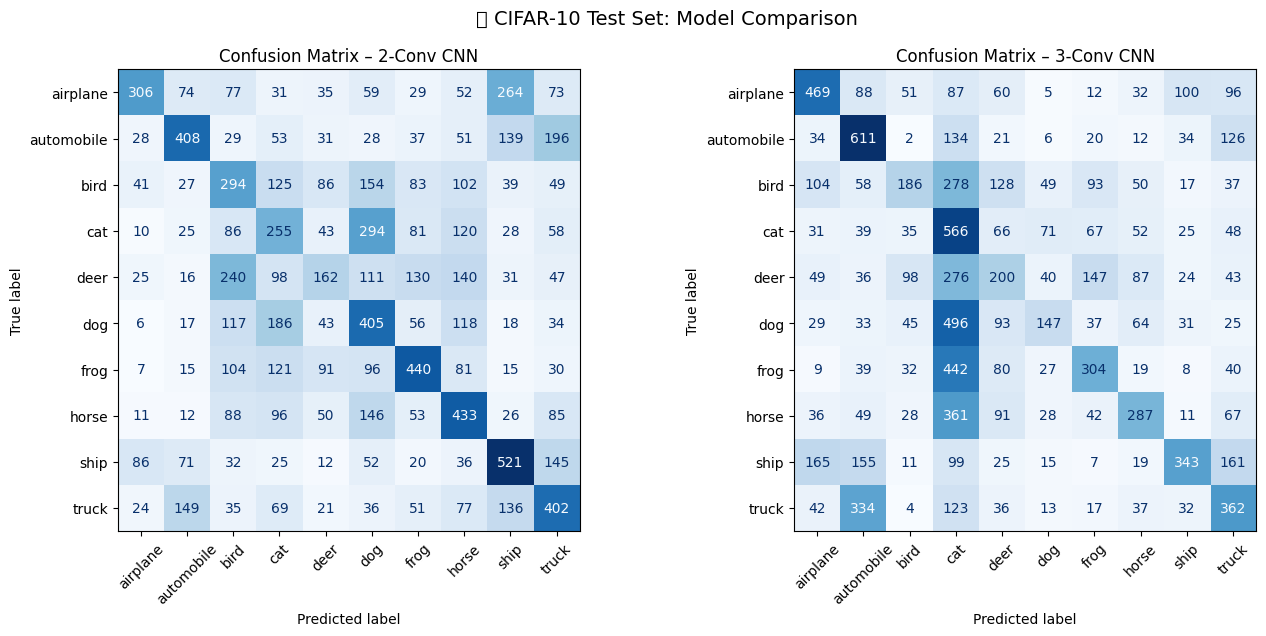

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Confusion Matrices for Model 1 and Model 2 (side by side)
# -----------------------------------------------------------

def get_preds_and_labels(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data, labels in loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

# Get predictions and labels
preds1, labels1 = get_preds_and_labels(model1, test_loader)
preds2, labels2 = get_preds_and_labels(model2, test_loader)

# Build confusion matrices
cm1 = confusion_matrix(labels1, preds1)
cm2 = confusion_matrix(labels2, preds2)

# CIFAR-10 class names
class_names = train_dataset.classes

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=class_names)
disp1.plot(cmap="Blues", ax=axes[0], xticks_rotation=45, colorbar=False)
axes[0].set_title("Confusion Matrix – 2-Conv CNN")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=class_names)
disp2.plot(cmap="Blues", ax=axes[1], xticks_rotation=45, colorbar=False)
axes[1].set_title("Confusion Matrix – 3-Conv CNN")

plt.suptitle("📊 CIFAR-10 Test Set: Model Comparison", fontsize=14)
plt.show()

## 📊 CNN Model Comparison 

### Results Recap
| Model                          | Test Accuracy | Parameters     |
|--------------------------------|---------------|----------------|
| 2-Conv CNN (11×11, 5×5)        | **36.26%**    | ~6,627,786     |
| 3-Conv CNN (3×3, 3×3, 3×3)     | 34.75%        | ~396,597,322 (!!) |

---

### 🔹 Comparative Analysis

#### **1. 2-Conv CNN (11×11, 5×5)**
**Strengths:**
- Fewer parameters (~6.6M) → lighter model, easier to train on limited hardware.
- Achieved higher accuracy (36.26%) despite being simpler.
- Large initial kernel (11×11) captures broad spatial features early on.

**Weaknesses:**
- Large filters risk losing fine-grained local details (edges, textures).
- Shallow depth (only 2 convolution layers) limits hierarchical feature learning.
- May not generalize well to more complex datasets.

---

#### **2. 3-Conv CNN (3×3, 3×3, 3×3)**
**Strengths:**
- Uses 3×3 kernels — the standard in modern CNNs (e.g., VGGNet).
- Deeper stack (3 conv layers) in theory enables hierarchical feature extraction.

**Weaknesses:**
- Extremely high parameter count (~397M) → **over-parameterized for CIFAR-10**.
- Root cause: the network resizes input images to **224×224**, and after three conv layers the flattened feature maps remain very large. Feeding this into a fully connected layer (FC1 → 1024) creates a massive parameter explosion.
- Leads to overfitting (memorization, poor generalization).
- Slower training, high GPU memory usage, inefficient.

---

### 🔑 Key Insight
- **More layers and parameters do not guarantee better performance.**
- The 2-Conv model balanced complexity and capacity, achieving higher accuracy with far fewer parameters.
- The 3-Conv model followed a conceptually stronger design (small filters, deeper hierarchy), but without dimension reduction (e.g., global average pooling), it became impractical.

---

### 💡 Next Steps for Improvement
- Reduce parameters in the 3-Conv CNN using:
  - Smaller fully connected layers.
  - **Global average pooling** instead of flattening into a huge dense layer.
  - BatchNorm + Dropout to stabilize and regularize training.
- Hybrid approach:
  - Keep 3×3 kernels but control channel sizes carefully.
  - Compare with smaller baselines like **LeNet-5** or a **mini-VGG** for CIFAR-10 scale tasks.

---

### ✅ Final Verdict
- **2-Conv CNN:** More efficient, better suited for small-scale lab experiments.
- **3-Conv CNN:** Conceptually closer to modern CNNs, but crippled by excessive parameters due to flattening → needs redesign to be practical.
